# Комментарии к блокноту

1. SELECTED_BASE_CONFIGS - захардкожены, список по результатам предыдущего теста

2. ГЕНЕРАЦИЯ PROMPT_VARIANTS - раскомментировать стратегию C

3. Блок #  ПРОВЕРКА СЕМАНТИЧЕСКИХ СТРАТЕГИЙ

закомментирован код для C стратегии
  #("C", "interleaved",  "C (interleaved)"),

# Возможные ошибки:

Сообщение про эмбендинги

  Маппинг train эмбеддингов:
    прямое совпадение : 0
    по session_id     : 0
    по row_idx        : 48
    не найдено        : 700
    итого             : 48 / 748 (6.4%)

  ⚠ ВНИМАНИЕ: более 10% записей без эмбеддинга!
  Проверьте EMBEDDING_ID_COLUMN='session_id'
  и cfg['id_column'] в коде построения эмбеддингов.
  Запустите diagnose_id_mismatch() для диагностики.

Матрица train эмбеддингов : (48, 4096)
Legal   матрица           : (9, 4096)
Illegal матрица           : (39, 4096)

Строим кэш val эмбеддингов...

  Кэш val эмбеддингов: найдено 61/336 (18.2%)
    прямое: 0 | session_id: 0 | row_idx: 61 | не найдено: 275
  ⚠ Более 10% val items без эмбеддинга!
  Проверьте соответствие ID (EMBEDDING_ID_COLUMN='session_id')
Оставшиеся плейсхолдеры: ['DRUG_TERMS', 'FEW_SHOT_EXAMPLES', 'INPUT_JSON']

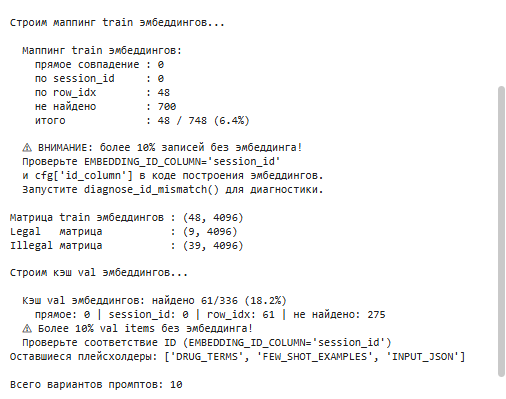

In [25]:
from __future__ import annotations

import math
from dotenv import load_dotenv
import os
from pydantic import BaseModel
import json
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from pathlib import Path
import time
import csv
import re

import asyncio
import nest_asyncio
import random
from dataclasses import dataclass
from typing import Any

from openai import AsyncOpenAI, APIConnectionError, APIStatusError, RateLimitError
from tqdm.asyncio import tqdm

In [2]:
import logging
import sys
from io import StringIO
from datetime import datetime

# ─────────────────────────────────────────────
# Настройка директории логов и RUN_ID
# ─────────────────────────────────────────────

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    drive_root = Path("/content/drive/MyDrive")
    if not drive_root.exists():
        raise FileNotFoundError(f"Drive примонтирован, но {drive_root} недоступен")
    LOG_DIR = drive_root / "logs"
    USE_DRIVE = True
    print(f"✅ Google Drive подключён.")
except Exception as e:
    LOG_DIR = Path("logs")
    USE_DRIVE = False
    print(f"⚠ Drive недоступен ({e}), логи сохраняются локально в ./logs/")

LOG_DIR.mkdir(parents=True, exist_ok=True)
assert LOG_DIR.exists(), f"Не удалось создать директорию логов: {LOG_DIR}"

print(f"RUN_ID   : {RUN_ID}")
print(f"LOG_DIR  : {LOG_DIR}")
print(f"Папка существует: {LOG_DIR.exists()}")
print(f"USE_DRIVE: {USE_DRIVE}")

Mounted at /content/drive
✅ Google Drive подключён.
RUN_ID   : 20260607_070439
LOG_DIR  : /content/drive/MyDrive/logs
Папка существует: True
USE_DRIVE: True


In [26]:
load_dotenv(".env")

BASE_URL        = os.getenv("BASE_URL")
API_KEY         = os.getenv("API_KEY")
MODEL_NAME      = "YandexGPT-5-Lite-8B-instruct"
MAX_CONCURRENCY = 256
TEMPERATURE     = 0
MAX_TEXT_LEN    = 1500

In [4]:
# ─────────────────────────────────────────────
# НАСТРОЙКИ ЭМБЕДДИНГОВ
# Должны совпадать с параметрами кода построения эмбеддингов
# ─────────────────────────────────────────────

# OUT_DIR из кода построения эмбеддингов
EMBEDDINGS_DIR = Path(".")

# cfg["name"] из кода построения эмбеддингов для каждого сплита
EMBEDDING_DATASET_NAMES = {
    "train": "train",
    "val":   "val",
    "test":  "test",
}

# cfg["id_column"] из кода построения эмбеддингов
# Если None — использовался порядковый индекс строки (0, 1, 2, ...)
EMBEDDING_ID_COLUMN = "session_id"


In [6]:
# ─────────────────────────────────────────────
# ЗАГРУЗКА СЛОВАРЯ
# ─────────────────────────────────────────────

def load_drug_terms(csv_path="illegal_terms_dictionary_edit.csv"):
    seen: set[tuple[str, str | None]] = set()
    items: list[dict] = []

    with open(csv_path, encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            term = (row.get("normalized_term") or "").strip()
            cat_raw = (row.get("category") or "").strip()
            if not term:
                continue
            term = re.sub(r"\([^)]*\)", "", term)
            if "(" in term or ")" in term or len(term) > 25:
                continue
            term = term.strip(" .,:;").lower()
            if len(term) < 2:
                continue
            category: str | None = cat_raw if cat_raw else None
            key = (term, category)
            if key in seen:
                continue
            seen.add(key)
            items.append({"term": term, "category": category})

    items.sort(key=lambda x: (x["term"], x["category"] or ""))
    return json.dumps(items, ensure_ascii=False)


def load_drug_terms_short(csv_path="illegal_terms_dictionary_edit.csv"):
    seen: set[str] = set()
    items: list[dict] = []

    with open(csv_path, encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            cat_raw = (row.get("category") or "").strip()
            if cat_raw != "drugs":
                continue
            term = (row.get("normalized_term") or "").strip()
            if not term:
                continue
            term = re.sub(r"\([^)]*\)", "", term)
            if "(" in term or ")" in term or len(term) > 25:
                continue
            term = term.strip(" .,:;").lower()
            if len(term) < 2:
                continue
            if term in seen:
                continue
            seen.add(term)
            items.append({"term": term, "category": "drugs"})

    items.sort(key=lambda x: x["term"])
    return json.dumps(items, ensure_ascii=False)


DRUG_TERMS       = load_drug_terms("illegal_terms_dictionary_edit.csv")
DRUG_TERMS_SHORT = load_drug_terms_short("illegal_terms_dictionary_edit.csv")

print(f"Загружено терминов в DRUG_TERMS: {len(json.loads(DRUG_TERMS))}")
print(f"Терминов в DRUG_TERMS_SHORT: {len(json.loads(DRUG_TERMS_SHORT))}")


Загружено терминов в DRUG_TERMS: 800
Терминов в DRUG_TERMS_SHORT: 104


In [7]:
# ─────────────────────────────────────────────
# ЗАГРУЗКА ДАТАСЕТОВ
# ─────────────────────────────────────────────

df_val   = pd.read_parquet("val.parquet").reset_index(drop=True)
df_test  = pd.read_parquet("test.parquet").reset_index(drop=True)
df_train = pd.read_parquet("train.parquet").reset_index(drop=True)


def row_to_input_json(row, idx):
    question = str(row["question"]) if pd.notna(row["question"]) else ""
    answer   = str(row["answer"])   if pd.notna(row["answer"])   else ""
    text = f"Вопрос: {question}\nОтвет: {answer}"
    return {
        "id":   f"{row['session_id']}___{idx}",
        "text": text[:MAX_TEXT_LEN],
    }


input_jsons = [row_to_input_json(row, idx) for idx, row in df_val.iterrows()]

print(f"\nВсего записей в val (подбор гиперпараметров): {len(input_jsons)}")
print(f"Уникальных session_id: {len({i['id'] for i in input_jsons})}")
print("\nПример:")
print(json.dumps(input_jsons[0], ensure_ascii=False, indent=2))

assert len({i["id"] for i in input_jsons}) == len(input_jsons), (
    "session_id не уникален в val.parquet!"
)



Всего записей в val (подбор гиперпараметров): 336
Уникальных session_id: 336

Пример:
{
  "id": "telegram-322189240-onlajn_zakazy-322189240-dJG-4163715281-5452102867.2de8f5e4-9fcc-c2b2-2acc-63fd3ca1803b___0",
  "text": "Вопрос: /newNode_7;Альфа-ПВП VHQ+ТОП 0.5гр.280грн\nОтвет: Избран продукт: Альфа-ПВП VHQ+ ТОП Прозрачные крисы 0.5 гр.\nКоротко о товаре: Всеми любимая и знакомая Альфа пвп. Очень мощные, прозрачные криссталы, высокого качества!!!\nЦена: 280 грн.\nВыберите подходящий район:"
}


In [8]:
# ─────────────────────────────────────────────
# ПОДГОТОВКА ДАННЫХ TRAIN ДЛЯ FEW-SHOT
# ─────────────────────────────────────────────

SEED_VALUE = 42
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)

T_GRID = [2, 4, 8, 16, 32]


def row_to_train_json(row, idx):
    question = str(row["question"]) if pd.notna(row["question"]) else ""
    answer   = str(row["answer"])   if pd.notna(row["answer"])   else ""
    text = f"Вопрос: {question}\nОтвет: {answer}"
    return {
        "id":    f"{row['session_id']}___{idx}",
        "text":  text[:MAX_TEXT_LEN],
        "label": int(row["from_illegal_account"]),
    }


examples_jsons = [row_to_train_json(row, idx) for idx, row in df_train.iterrows()]

examples_id    = [item["id"]    for item in examples_jsons]
examples_text  = [item["text"]  for item in examples_jsons]
examples_label = [item["label"] for item in examples_jsons]

print(f"\nВсего записей в train : {len(examples_id)}")
print(f"Уникальных session_id : {len(set(examples_id))}")
print(f"Legal   (0)           : {examples_label.count(0)}")
print(f"Illegal (1)           : {examples_label.count(1)}")

assert len(set(examples_id)) == len(examples_id), (
    "session_id не уникален в train.parquet!"
)

legal_indices   = [i for i, lbl in enumerate(examples_label) if lbl == 0]
illegal_indices = [i for i, lbl in enumerate(examples_label) if lbl == 1]


# ─────────────────────────────────────────────
# ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ КОНВЕРТАЦИИ МЕТОК
# Объявляем ДО load_embeddings, т.к. используется внутри неё
# ─────────────────────────────────────────────

def _convert_labels_to_int(labels_raw: np.ndarray, split: str) -> np.ndarray:
    """
    Конвертирует метки из dtype=object в int (0/1).

    Код построения эмбеддингов сохраняет метки как:
        np.asarray(labels, dtype=object)
    Метки могут быть строками, int, float или bool в зависимости
    от значений в label_column датасета.

    Поддерживаемые форматы:
        bool            → int(lbl)           # проверяем ДО int (bool наследует int)
        int / float     → int(lbl)
        "1" / "illegal" / "true" / "yes"  → 1
        "0" / "legal"   / "false" / "no"  → 0
    """
    result = np.zeros(len(labels_raw), dtype=int)
    unknown_values: set = set()

    for i, lbl in enumerate(labels_raw):
        if lbl is None:
            result[i] = 0
            continue

        # bool проверяем ДО int (bool является подклассом int в Python)
        if isinstance(lbl, (bool, np.bool_)):
            result[i] = int(lbl)
            continue

        # int / float
        if isinstance(lbl, (int, float, np.integer, np.floating)):
            result[i] = int(lbl)
            continue

        # строки
        s = str(lbl).strip().lower()
        if s in ("1", "true", "illegal", "yes", "positive"):
            result[i] = 1
        elif s in ("0", "false", "legal", "no", "negative"):
            result[i] = 0
        else:
            result[i] = 0
            unknown_values.add(s)

    if unknown_values:
        print(
            f"  [{split}] ⚠ Неизвестные значения меток (заменены на 0): "
            f"{unknown_values}"
        )

    return result


Всего записей в train : 748
Уникальных session_id : 748
Legal   (0)           : 182
Illegal (1)           : 566


In [9]:
# ─────────────────────────────────────────────
# ЗАГРУЗКА ЭМБЕДДИНГОВ
# ─────────────────────────────────────────────

def load_embeddings(split: str, emb_dir: Path = EMBEDDINGS_DIR) -> dict:
    """
    Загружает эмбеддинги для указанного сплита из .npy файлов.

    Особенности кода построения эмбеддингов (Qwen3-Embedding-8B):
        - embeddings: float32, normalize_embeddings=True → уже L2-нормализованы
        - ids:        np.asarray(ids, dtype=object)      → allow_pickle=True обязателен
        - labels:     np.asarray(labels, dtype=object)   → allow_pickle=True обязателен

    ВАЖНО: allow_pickle=True используется для ВСЕХ трёх файлов,
    т.к. numpy при dtype=object записывает pickle-заголовок даже для
    числовых массивов, и без allow_pickle=True возникает ValueError.

    Args:
        split:   "train", "val" или "test"
        emb_dir: директория с .npy файлами (= OUT_DIR кода построения)

    Returns:
        dict:
            "embeddings"        — np.ndarray (N, D) float32, исходные
            "embeddings_normed" — np.ndarray (N, D) float32, нормализованные
            "ids"               — np.ndarray (N,)   строковые ID
            "labels"            — np.ndarray (N,)   int (0/1) или None
            "id_to_idx"         — dict {str_id: int_index}
    """
    dataset_name = EMBEDDING_DATASET_NAMES[split]
    emb_path     = emb_dir / f"{dataset_name}_embeddings.npy"
    ids_path     = emb_dir / f"{dataset_name}_ids.npy"
    labels_path  = emb_dir / f"{dataset_name}_labels.npy"

    # ── Проверка существования файлов ────────────────────────────────
    if not emb_path.exists():
        raise FileNotFoundError(
            f"Файл эмбеддингов не найден: {emb_path}\n"
            f"Проверьте:\n"
            f"  EMBEDDINGS_DIR = '{emb_dir}' (должно совпадать с OUT_DIR)\n"
            f"  EMBEDDING_DATASET_NAMES['{split}'] = '{dataset_name}' "
            f"(должно совпадать с cfg['name'])"
        )
    if not ids_path.exists():
        raise FileNotFoundError(f"Файл IDs не найден: {ids_path}")

    # ── Эмбеддинги ───────────────────────────────────────────────────
    # allow_pickle=True: безопасно для собственных файлов;
    # необходимо т.к. numpy может записать object-заголовок
    embeddings = np.load(emb_path, allow_pickle=True).astype(np.float32)

    # Проверяем, нормализованы ли эмбеддинги (ожидаем ||v|| ≈ 1.0)
    # Код построения: normalize_embeddings=True → должны быть нормализованы
    n_check      = min(100, len(embeddings))
    sample_norms = np.linalg.norm(embeddings[:n_check], axis=1)
    already_normalized = bool(np.allclose(sample_norms, 1.0, atol=1e-3))

    if already_normalized:
        # Эмбеддинги уже нормализованы — используем как есть
        embeddings_normed = embeddings
    else:
        # Нештатная ситуация: normalize_embeddings=False в коде построения
        print(
            f"  [{split}] ⚠ Эмбеддинги не нормализованы "
            f"(mean_norm={sample_norms.mean():.4f}), нормализуем вручную"
        )
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        norms = np.where(norms == 0, 1.0, norms)
        embeddings_normed = (embeddings / norms).astype(np.float32)

    # ── IDs ──────────────────────────────────────────────────────────
    # Код построения: np.asarray(ids, dtype=object)
    # → allow_pickle=True ОБЯЗАТЕЛЕН, иначе ValueError
    ids_raw = np.load(ids_path, allow_pickle=True)
    ids = np.array([str(x) for x in ids_raw], dtype=object)

    # ── Labels ───────────────────────────────────────────────────────
    # Код построения: np.asarray(labels, dtype=object)
    # → allow_pickle=True ОБЯЗАТЕЛЕН
    labels = None
    if labels_path.exists():
        labels_raw = np.load(labels_path, allow_pickle=True)
        labels = _convert_labels_to_int(labels_raw, split)
    else:
        print(f"  [{split}] ⚠ Файл меток не найден: {labels_path}")

    # ── Проверка согласованности размеров ────────────────────────────
    assert embeddings.shape[0] == len(ids), (
        f"[{split}] Несовпадение размеров: "
        f"embeddings={embeddings.shape[0]}, ids={len(ids)}"
    )
    if labels is not None:
        assert embeddings.shape[0] == len(labels), (
            f"[{split}] Несовпадение размеров: "
            f"embeddings={embeddings.shape[0]}, labels={len(labels)}"
        )

    # ── Индекс id → позиция в матрице ────────────────────────────────
    id_to_idx: dict[str, int] = {str(eid): i for i, eid in enumerate(ids)}

    n_legal   = int(np.sum(labels == 0)) if labels is not None else -1
    n_illegal = int(np.sum(labels == 1)) if labels is not None else -1

    print(
        f"  [{split}] shape={embeddings.shape} | "
        f"normalized={already_normalized} | "
        f"legal={n_legal} | illegal={n_illegal}"
    )

    return {
        "embeddings":        embeddings,
        "embeddings_normed": embeddings_normed,
        "ids":               ids,
        "labels":            labels,
        "id_to_idx":         id_to_idx,
    }


print("\nЗагружаем эмбеддинги...")
EMBEDDINGS_TRAIN = load_embeddings("train")
EMBEDDINGS_VAL   = load_embeddings("val")
EMBEDDINGS_TEST  = load_embeddings("test")

print(f"\n✅ Все эмбеддинги загружены")
print(f"  train : {EMBEDDINGS_TRAIN['embeddings'].shape}")
print(f"  val   : {EMBEDDINGS_VAL['embeddings'].shape}")
print(f"  test  : {EMBEDDINGS_TEST['embeddings'].shape}")



Загружаем эмбеддинги...
  [train] ⚠ Эмбеддинги не нормализованы (mean_norm=1.0013), нормализуем вручную
  [train] shape=(748, 4096) | normalized=False | legal=531 | illegal=217
  [val] ⚠ Эмбеддинги не нормализованы (mean_norm=1.0018), нормализуем вручную
  [val] shape=(336, 4096) | normalized=False | legal=193 | illegal=143
  [test] ⚠ Эмбеддинги не нормализованы (mean_norm=1.0017), нормализуем вручную
  [test] shape=(305, 4096) | normalized=False | legal=202 | illegal=103

✅ Все эмбеддинги загружены
  train : (748, 4096)
  val   : (336, 4096)
  test  : (305, 4096)


In [10]:
# ─────────────────────────────────────────────
# СОПОСТАВЛЕНИЕ ID ЭМБЕДДИНГОВ С ИНДЕКСАМИ TRAIN
#
# Проблема: ID в .npy формируются кодом построения из cfg["id_column"],
# а examples_id формируется как f"{session_id}___{row_idx}".
#
# Стратегии поиска (в порядке приоритета):
#   1. Прямое совпадение: emb_id == examples_id
#   2. По session_id: часть до "___" в examples_id
#   3. По row_idx:   часть после "___" (если id_column не задан → "0","1","2"...)
# ─────────────────────────────────────────────

def diagnose_id_mismatch(
    examples_ids: list[str],
    emb_ids: np.ndarray,
    n_show: int = 5,
) -> None:
    """
    Диагностический вывод при несовпадении ID.
    Показывает примеры из обоих источников для ручной проверки.
    """
    print(f"\n  {'─'*55}")
    print(f"  ДИАГНОСТИКА ID")
    print(f"  {'─'*55}")
    print(f"  Примеры examples_id (parquet + row_to_train_json):")
    for eid in list(examples_ids)[:n_show]:
        print(f"    '{eid}'")
    print(f"  Примеры emb_id (из .npy, код построения эмбеддингов):")
    for eid in list(emb_ids)[:n_show]:
        print(f"    '{eid}'")
    print(
        f"\n  Текущий EMBEDDING_ID_COLUMN = '{EMBEDDING_ID_COLUMN}'\n"
        f"  Если emb_id — это '0','1','2'... → id_column не задан,\n"
        f"  установите EMBEDDING_ID_COLUMN = None"
    )
    print(f"  {'─'*55}")


def build_train_emb_mapping(
    examples_ids: list[str],
    emb_id_to_idx: dict[str, int],
) -> tuple[list[int], list[int]]:
    """
    Строит маппинг examples_idx → emb_matrix_idx.

    Returns:
        matched_example_indices — индексы в examples_* с найденным эмбеддингом
        matched_emb_indices     — соответствующие индексы в матрице эмбеддингов
    """
    matched_example_indices: list[int] = []
    matched_emb_indices: list[int]     = []
    strategy_counts = {"direct": 0, "session_id": 0, "row_idx": 0, "failed": 0}

    for ex_idx, ex_id in enumerate(examples_ids):

        # Стратегия 1: прямое совпадение
        if ex_id in emb_id_to_idx:
            matched_example_indices.append(ex_idx)
            matched_emb_indices.append(emb_id_to_idx[ex_id])
            strategy_counts["direct"] += 1
            continue

        # Стратегия 2: по session_id (часть до "___")
        if "___" in ex_id:
            session_part = ex_id.split("___")[0]
            if session_part in emb_id_to_idx:
                matched_example_indices.append(ex_idx)
                matched_emb_indices.append(emb_id_to_idx[session_part])
                strategy_counts["session_id"] += 1
                continue

        # Стратегия 3: по порядковому индексу строки (часть после "___")
        if "___" in ex_id:
            try:
                row_idx_str = str(int(ex_id.split("___")[1]))
                if row_idx_str in emb_id_to_idx:
                    matched_example_indices.append(ex_idx)
                    matched_emb_indices.append(emb_id_to_idx[row_idx_str])
                    strategy_counts["row_idx"] += 1
                    continue
            except (ValueError, IndexError):
                pass

        strategy_counts["failed"] += 1

    total    = len(examples_ids)
    matched  = len(matched_example_indices)
    failed   = strategy_counts["failed"]

    print(f"\n  Маппинг train эмбеддингов:")
    print(f"    прямое совпадение : {strategy_counts['direct']}")
    print(f"    по session_id     : {strategy_counts['session_id']}")
    print(f"    по row_idx        : {strategy_counts['row_idx']}")
    print(f"    не найдено        : {failed}")
    print(f"    итого             : {matched} / {total} "
          f"({100*matched/total:.1f}%)")

    if failed > total * 0.1:
        print(
            f"\n  ⚠ ВНИМАНИЕ: более 10% записей без эмбеддинга!\n"
            f"  Проверьте EMBEDDING_ID_COLUMN='{EMBEDDING_ID_COLUMN}'\n"
            f"  и cfg['id_column'] в коде построения эмбеддингов.\n"
            f"  Запустите diagnose_id_mismatch() для диагностики."
        )

    return matched_example_indices, matched_emb_indices


def build_val_emb_cache(
    input_jsons: list[dict],
    emb_id_to_idx: dict[str, int],
    embeddings_normed: np.ndarray,
) -> tuple[dict[str, np.ndarray], dict]:
    """
    Строит кэш {item_id → normed_embedding} для val items.

    Использует те же три стратегии поиска, что build_train_emb_mapping.

    Returns:
        cache: dict {item_id: np.ndarray}
        stats: статистика совпадений
    """
    cache: dict[str, np.ndarray] = {}
    stats = {"direct": 0, "session_id": 0, "row_idx": 0, "failed": 0}

    for item in input_jsons:
        item_id = item["id"]
        emb_vec = None

        # Стратегия 1: прямое совпадение
        if item_id in emb_id_to_idx:
            emb_vec = embeddings_normed[emb_id_to_idx[item_id]]
            stats["direct"] += 1

        # Стратегия 2: по session_id
        elif "___" in item_id:
            session_part = item_id.split("___")[0]
            if session_part in emb_id_to_idx:
                emb_vec = embeddings_normed[emb_id_to_idx[session_part]]
                stats["session_id"] += 1

        # Стратегия 3: по row_idx
        if emb_vec is None and "___" in item_id:
            try:
                row_idx_str = str(int(item_id.split("___")[1]))
                if row_idx_str in emb_id_to_idx:
                    emb_vec = embeddings_normed[emb_id_to_idx[row_idx_str]]
                    stats["row_idx"] += 1
            except (ValueError, IndexError):
                pass

        if emb_vec is not None:
            cache[item_id] = emb_vec
        else:
            stats["failed"] += 1

    total = len(input_jsons)
    found = total - stats["failed"]
    print(f"\n  Кэш val эмбеддингов: найдено {found}/{total} "
          f"({100*found/total:.1f}%)")
    print(f"    прямое: {stats['direct']} | "
          f"session_id: {stats['session_id']} | "
          f"row_idx: {stats['row_idx']} | "
          f"не найдено: {stats['failed']}")

    if stats["failed"] > total * 0.1:
        print(
            f"  ⚠ Более 10% val items без эмбеддинга!\n"
            f"  Проверьте соответствие ID (EMBEDDING_ID_COLUMN='{EMBEDDING_ID_COLUMN}')"
        )

    return cache, stats


# ── Диагностика ID перед маппингом ───────────────────────────────────
diagnose_id_mismatch(examples_id, EMBEDDINGS_TRAIN["ids"])

# ── Маппинг train ─────────────────────────────────────────────────────
print("\nСтроим маппинг train эмбеддингов...")
(
    _train_matched_ex_indices,
    _train_matched_emb_indices,
) = build_train_emb_mapping(
    examples_ids=examples_id,
    emb_id_to_idx=EMBEDDINGS_TRAIN["id_to_idx"],
)

# Маппинг: examples_idx → emb_matrix_idx
_ex_idx_to_emb_idx: dict[int, int] = dict(
    zip(_train_matched_ex_indices, _train_matched_emb_indices)
)

# Упорядоченный список examples_* индексов с эмбеддингами
train_indices_with_emb: list[int] = _train_matched_ex_indices

# ── Матрица всех train эмбеддингов ───────────────────────────────────
# Строка i соответствует train_indices_with_emb[i]
_train_emb_matrix = np.stack([
    EMBEDDINGS_TRAIN["embeddings_normed"][_ex_idx_to_emb_idx[ex_idx]]
    for ex_idx in train_indices_with_emb
], axis=0).astype(np.float32)  # (M, D)

# ── Маски и матрицы по классам ────────────────────────────────────────
_legal_mask_in_matrix   = np.array(
    [examples_label[i] == 0 for i in train_indices_with_emb], dtype=bool
)
_illegal_mask_in_matrix = ~_legal_mask_in_matrix

# Глобальные индексы в том же порядке, что строки матриц по классам
_legal_global_indices_ordered   = [
    i for i in train_indices_with_emb if examples_label[i] == 0
]
_illegal_global_indices_ordered = [
    i for i in train_indices_with_emb if examples_label[i] == 1
]

# Отдельные матрицы по классам (для быстрого поиска внутри класса)
_legal_emb_matrix   = _train_emb_matrix[_legal_mask_in_matrix]    # (N_legal,  D)
_illegal_emb_matrix = _train_emb_matrix[_illegal_mask_in_matrix]  # (N_illegal, D)

print(f"\nМатрица train эмбеддингов : {_train_emb_matrix.shape}")
print(f"Legal   матрица           : {_legal_emb_matrix.shape}")
print(f"Illegal матрица           : {_illegal_emb_matrix.shape}")

# ── Кэш val эмбеддингов ───────────────────────────────────────────────
print("\nСтроим кэш val эмбеддингов...")
_VAL_EMB_CACHE, _val_cache_stats = build_val_emb_cache(
    input_jsons=input_jsons,
    emb_id_to_idx=EMBEDDINGS_VAL["id_to_idx"],
    embeddings_normed=EMBEDDINGS_VAL["embeddings_normed"],
)


def _get_val_emb(item_id: str) -> np.ndarray | None:
    """Быстрый доступ к нормализованному эмбеддингу val по item_id."""
    return _VAL_EMB_CACHE.get(str(item_id))


  ───────────────────────────────────────────────────────
  ДИАГНОСТИКА ID
  ───────────────────────────────────────────────────────
  Примеры examples_id (parquet + row_to_train_json):
    'telegram-8412110593-adyoika-8412110593-NOn-52042546487-291055363.5c994b1d-11bd-03ae-a6ff-a7e1b7bcee21___0'
    'telegram-322189240-onlajn_zakazy-322189240-dJG-4163715281-3403583115.7ce9083d-1d9e-471e-1627-1f14df2bb9fe___1'
    'telegram-8412110593-adyoika-8412110593-NOn-52042546487-7960763363.c932fffa-ed34-35d2-232a-08d0faae963c___2'
    'telegram-8412110593-adyoika-8412110593-NOn-52042546487-291055363.5c994b1d-11bd-03ae-a6ff-a7e1b7bcee21___3'
    'telegram-183263525-massatela1_startapy_-183263525-gul-14644976955-2827676841.fd9d5fc0-b440-740e-0b23-797ececa63ed___4'
  Примеры emb_id (из .npy, код построения эмбеддингов):
    '0'
    '1'
    '2'
    '3'
    '4'

  Текущий EMBEDDING_ID_COLUMN = 'session_id'
  Если emb_id — это '0','1','2'... → id_column не задан,
  установите EMBEDDING_ID_COLUMN = No

In [11]:
# ─────────────────────────────────────────────
# ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ ВЫВОДА
# ─────────────────────────────────────────────

def print_samples(indices: list, title: str):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    for idx in sorted(indices):
        label_str = "illegal" if examples_label[idx] == 1 else "legal"
        print(f"\n[{label_str}]")
        print(examples_text[idx])
        print("-" * 40)

In [12]:
# ─────────────────────────────────────────────
# СТРАТЕГИИ ОТБОРА ПРИМЕРОВ
# ─────────────────────────────────────────────

def sample_random(t: int) -> list:
    """Вариант 1 — t случайных примеров."""
    return random.sample(range(len(examples_id)), t)


def sample_balanced(t: int) -> list:
    """Вариант 2 — t примеров, соотношение 1:1 (legal:illegal)."""
    n_illegal = t // 2
    n_legal   = t // 2
    remainder = t % 2

    sampled_legal   = random.sample(legal_indices,   n_legal)
    sampled_illegal = random.sample(illegal_indices, n_illegal)

    if remainder:
        extra_pool = (
            [i for i in legal_indices   if i not in sampled_legal] +
            [i for i in illegal_indices if i not in sampled_illegal]
        )
        sampled_illegal += random.sample(extra_pool, remainder)

    result = sampled_legal + sampled_illegal
    assert len(result) == t, f"balanced: ожидалось {t}, получено {len(result)}"
    return result


def sample_2to1(t: int) -> list:
    """Вариант 3 — t примеров, соотношение 2:1 (legal:illegal)."""
    n_illegal = max(1, round(t / 3))
    n_legal   = t - n_illegal
    n_illegal = min(n_illegal, len(illegal_indices))
    n_legal   = min(n_legal,   len(legal_indices))
    actual_t  = n_legal + n_illegal

    result = (
        random.sample(legal_indices,   n_legal) +
        random.sample(illegal_indices, n_illegal)
    )
    assert len(result) == actual_t
    return result

In [13]:
# ─────────────────────────────────────────────
# СТРАТЕГИЯ A: Топ-N по семантике (closest-last)
# ─────────────────────────────────────────────

def sample_top_n_semantic(
    query_emb: np.ndarray,
    t: int,
    order: str = "closest_last",
) -> list[int]:
    """
    Стратегия A: выбирает t наиболее семантически похожих примеров
    из обучающей выборки без учёта классов.

    Шаги:
        1. Косинусное сходство query vs все train эмбеддинги
           (dot product корректен, т.к. эмбеддинги нормализованы)
        2. Выбрать t примеров по убыванию сходства
        3. Упорядочить closest-last: наименее похожий первым,
           наиболее похожий последним (ближе к тестовому документу в промпте)

    Args:
        query_emb: нормализованный эмбеддинг запроса, shape (D,)
        t:         количество примеров
        order:     "closest_last"  — наименее похожий первый (рекомендуется)
                   "closest_first" — наиболее похожий первый

    Returns:
        Список глобальных индексов в examples_* в порядке для промпта.
    """
    # Шаг 1: косинусное сходство = dot product (эмбеддинги нормализованы)
    similarities = _train_emb_matrix @ query_emb  # (M,)

    # Шаг 2: топ-t по убыванию сходства
    actual_t = min(t, len(train_indices_with_emb))

    # np.argpartition: O(M) vs O(M log M) для полного argsort
    if actual_t < len(similarities):
        top_mi = np.argpartition(similarities, -actual_t)[-actual_t:]
        # Досортируем только топ-t элементов
        top_mi = top_mi[np.argsort(similarities[top_mi])[::-1]]
    else:
        top_mi = np.argsort(similarities)[::-1]

    # Перевод матричных индексов в глобальные индексы examples_*
    # top_mi[0] → самый похожий, top_mi[-1] → наименее похожий
    global_indices_by_sim_desc = [train_indices_with_emb[mi] for mi in top_mi]

    # Шаг 3: упорядочивание для промпта
    if order == "closest_last":
        # [наименее похожий, ..., наиболее похожий]
        # Самый похожий — в конце промпта, ближе к тестовому документу
        return list(reversed(global_indices_by_sim_desc))
    else:
        # closest_first: [наиболее похожий, ..., наименее похожий]
        return global_indices_by_sim_desc


In [14]:
# ─────────────────────────────────────────────
# СТРАТЕГИЯ B: Топ-N по семантике + балансировка по классам
# ─────────────────────────────────────────────

def sample_top_n_semantic_balanced(
    query_emb: np.ndarray,
    t: int,
    order: str = "closest_last",
) -> list[int]:
    """
    Стратегия B: N/2 наиболее похожих legal + N/2 наиболее похожих illegal.

    Шаги (из ТЗ):
        1. Разделить примеры train по классам
        2. Косинусное сходство query vs каждый train эмбеддинг
        3. Выбрать N/2 топ-похожих legal и N/2 топ-похожих illegal
        4. Упорядочить: closest-last или interleaved

    Args:
        query_emb: нормализованный эмбеддинг запроса, shape (D,)
        t:         общее количество примеров (лучше чётное)
        order:     "closest_last" — объединить оба класса, сортировать по возр. sim
                   "interleaved"  — чередование legal/illegal (→ стратегия C)

    Returns:
        Список глобальных индексов в нужном порядке для промпта.
    """
    n_illegal = t // 2
    n_legal   = t - n_illegal  # при нечётном t: legal на 1 больше

    # Шаг 1-2: косинусное сходство внутри каждого класса
    sim_legal   = _legal_emb_matrix   @ query_emb  # (N_legal,)
    sim_illegal = _illegal_emb_matrix @ query_emb  # (N_illegal,)

    def _top_k(
        sim_vec: np.ndarray,
        global_idx_list: list[int],
        k: int,
    ) -> list[tuple[int, float]]:
        """
        Возвращает [(global_idx, sim_value), ...] топ-k по убыванию сходства.
        """
        k = min(k, len(sim_vec))
        if k == 0:
            return []
        if k < len(sim_vec):
            top_mi = np.argpartition(sim_vec, -k)[-k:]
            top_mi = top_mi[np.argsort(sim_vec[top_mi])[::-1]]
        else:
            top_mi = np.argsort(sim_vec)[::-1]
        return [(global_idx_list[mi], float(sim_vec[mi])) for mi in top_mi]

    # Шаг 3: топ-k по каждому классу
    top_legal_ws   = _top_k(sim_legal,   _legal_global_indices_ordered,   n_legal)
    top_illegal_ws = _top_k(sim_illegal, _illegal_global_indices_ordered, n_illegal)

    # Шаг 4: упорядочивание для промпта
    if order == "interleaved":
        # Чередование: legal[0], illegal[0], legal[1], illegal[1], ...
        # Индекс 0 = наиболее похожий → переворачиваем для closest-last логики
        interleaved: list[int] = []
        max_len = max(len(top_legal_ws), len(top_illegal_ws))
        for i in range(max_len):
            if i < len(top_legal_ws):
                interleaved.append(top_legal_ws[i][0])
            if i < len(top_illegal_ws):
                interleaved.append(top_illegal_ws[i][0])
        # reversed → наиболее похожие ближе к концу промпта
        return list(reversed(interleaved))

    else:
        # closest_last: объединяем оба класса, сортируем по возрастанию sim
        # → наименее похожие первыми, наиболее похожие последними
        combined = top_legal_ws + top_illegal_ws
        combined_asc = sorted(combined, key=lambda x: x[1])
        return [idx for idx, _ in combined_asc]

In [15]:
'''# ─────────────────────────────────────────────
# СТРАТЕГИЯ C: Топ-N по семантике + чередование меток
# ─────────────────────────────────────────────

def sample_top_n_semantic_interleaved(
    query_emb: np.ndarray,
    t: int,
) -> list[int]:
    """
    Стратегия C: балансировка по классам с чередованием меток в промпте.

    Порядок в промпте: legal, illegal, legal, illegal, ...
    (наиболее похожие — ближе к концу промпта).

    Обёртка над sample_top_n_semantic_balanced(order="interleaved").
    """
    return sample_top_n_semantic_balanced(
        query_emb=query_emb,
        t=t,
        order="interleaved",
    )'''

'# ─────────────────────────────────────────────\n# СТРАТЕГИЯ C: Топ-N по семантике + чередование меток\n# ─────────────────────────────────────────────\n\ndef sample_top_n_semantic_interleaved(\n    query_emb: np.ndarray,\n    t: int,\n) -> list[int]:\n    """\n    Стратегия C: балансировка по классам с чередованием меток в промпте.\n\n    Порядок в промпте: legal, illegal, legal, illegal, ...\n    (наиболее похожие — ближе к концу промпта).\n\n    Обёртка над sample_top_n_semantic_balanced(order="interleaved").\n    """\n    return sample_top_n_semantic_balanced(\n        query_emb=query_emb,\n        t=t,\n        order="interleaved",\n    )'

In [16]:
# ─────────────────────────────────────────────
# SemanticSampler — callable-адаптер для семантических стратегий
# ─────────────────────────────────────────────

class SemanticSampler:
    """
    Callable-объект, совместимый с интерфейсом sample_fn(t: int) → list[int].

    Создаётся заново для каждого item (query_emb зависит от документа).

    Использование:
        sampler = SemanticSampler(query_emb, strategy="A", order="closest_last")
        indices = sampler(t=8)  # → list[int]
    """

    def __init__(
        self,
        query_emb: np.ndarray,
        strategy: str = "A",
        order: str = "closest_last",
    ):
        """
        Args:
            query_emb: нормализованный эмбеддинг тестового документа
            strategy:  "A" — top-N, "B" — balanced, "C" — interleaved
            order:     "closest_last" или "interleaved" (для B/C)
        """
        self.query_emb = query_emb
        self.strategy  = strategy
        self.order     = order

    def __call__(self, t: int) -> list[int]:
        if self.strategy == "A":
            return sample_top_n_semantic(self.query_emb, t, self.order)
        elif self.strategy == "B":
            return sample_top_n_semantic_balanced(self.query_emb, t, self.order)
        elif self.strategy == "C":
            return sample_top_n_semantic_interleaved(self.query_emb, t)
        else:
            raise ValueError(f"Неизвестная стратегия: {self.strategy!r}")

In [17]:
# ─────────────────────────────────────────────
# ПРОМПТЫ
# ─────────────────────────────────────────────

SYSTEM_PROMPT = "Ты - помощник по классификации текста для задачи модерации на предмет упоминания наркотиков."

prompt_d = """РОЛЬ:
Ты — высокоточная система бинарной классификации (NLP-модель), предназначенная для модерации сообщений Telegram. Твоя цель — максимально точно (с приоритетом на высокий F1-score) определять наличие упоминаний наркотических и психоактивных веществ.

ЗАДАЧА:
Определи, содержит ли текст сообщения упоминания наркотиков или связанной с ними деятельности.

ФОРМАТ ВХОДА:
JSON с полями:
- id: идентификатор сообщения
- text: текст сообщения (единственный источник анализа)

ФОРМАТ ВЫХОДА:
Строго JSON: {{"has_drug_mention": true | false}}

ОПРЕДЕЛЕНИЕ КЛАССА true:
Ставь true, если выполнено ХОТЯ БЫ ОДНО из условий:

1. Прямое упоминание наркотиков:
   - каннабис, марихуана, гашиш, кокаин, героин, амфетамин, метамфетамин, экстази, LSD и т.д.
   - любые термины из словаря ниже (полное или частичное совпадение по корню)

2. Прямое упоминание сущностей, связанных с наркотиками и наркоторговлей:
   - обменник, клад, кладмен, фасовка, закладка и т.д.

2. Сленг, жаргон, эвфемизмы:
   - шишки, травка, соль (в наркотическом контексте), меф, спиды, колёса, бошки и т.д.
   - английский сленг: weed, coke, meth, molly, acid и т.д.

3. Намеренно искажённые слова, особенно в названиях каналов и ботов через @:
   - замены символов: м@рuху@на, к0к@ин, мефедр0н
   - добавление лишних символов: DeaIler
   - пробелы/разделители: "м е ф", "к о к с"
   - транслит: marikhuana, geroin, mefedron

4. Контекст действий:
   - покупка, продажа, обмен, доставка, закладки
   - употребление, хранение, производство
   - поиск: "где взять", "купить", "есть ли", "ищу"

5. Подозрительные аббревиатуры и одиночные буквы латиницей в качестве вопроса:
   - Bbgg, Sh, I, CV GK j

6. Упоминания криптокошельков и криптовалют

7. Фразы с двойным дном и иносказания:
   - Главное не забывать: счастье — это когда ты нашёл, а тебя нет!

8. Косвенные сигналы:
   - эмодзи: 💊 🌿 🍁 ❄️ 🔥 🚬 💉
   - сочетание нейтральных слов с подозрительным контекстом

9. Частично неоднозначные случаи:
   - если есть разумное подозрение на наркотический контекст → true

СЛОВАРЬ ТЕРМИНОВ НАРКОТИЧЕСКОЙ ТЕМАТИКИ (список объектов с term и category — используй как опорный список):
{DRUG_TERMS}

ОПРЕДЕЛЕНИЕ КЛАССА false:
Ставь false, если:

1. Упоминания отсутствуют полностью
2. Слова-омонимы используются в бытовом значении:
   - "соль", "сахар", "таблетки" без контекста наркотиков
3. Лекарства:
   - если это медицинский контекст без признаков злоупотребления
4. Явная ирония или метафоры:
   - "я подсел на кофе как на наркотик"
5. Общие разговоры без связи с наркотиками

ПРИОРИТЕТ ПРИНЯТИЯ РЕШЕНИЯ (ВАЖНО ДЛЯ F1):
1. Контекст > отдельные слова
2. Словарь (DRUG_TERMS) > эвристики
3. Лучше false, чем ложный true ТОЛЬКО если нет достаточных сигналов
4. Но при слабом, но логичном подозрении → true

АЛГОРИТМ (внутренний):
1. Нормализуй текст:
   - приведи к нижнему регистру
   - убери спецсимволы
   - учти замены символов и транслит
2. Проверь совпадения со словарём DRUG_TERMS (term и его category помогут понять контекст: drugs/drug_trade/drug_effect/instruments/general/crypto_payment)
3. Проверь сленг и искажения
4. Проанализируй контекст (действия + объекты)
5. Учти эмодзи
6. Прими бинарное решение

ОГРАНИЧЕНИЯ:
- Используй ТОЛЬКО поле text
- НЕ добавляй объяснений
- НЕ добавляй новых полей
- НЕ изменяй структуру JSON
- Ответ ДОЛЖЕН быть валидным JSON

ПРИМЕР:

ВХОД:
{{
  "id": "abc__0",
  "text": "где купить меф?"
}}

ВЫХОД:
{{"has_drug_mention": true}}

ПРИМЕРЫ ИЗ ОБУЧАЮЩЕЙ ВЫБОРКИ:
{FEW_SHOT_EXAMPLES}

ВХОДНОЙ JSON ДЛЯ КЛАССИФИКАЦИИ:
{INPUT_JSON}
"""

In [18]:
KNOWN_PLACEHOLDERS = {"FEW_SHOT_EXAMPLES", "DRUG_TERMS", "INPUT_JSON"}


def escape_unknown_placeholders(text: str, known: set) -> str:
    def replacer(m):
        key = m.group(1)
        return f"{{{{{key}}}}}" if key not in known else m.group(0)
    return re.sub(r'\{(\w+)\}', replacer, text)


prompt_d = escape_unknown_placeholders(prompt_d, KNOWN_PLACEHOLDERS)

remaining = re.findall(r'\{(\w+)\}', prompt_d)
print("Оставшиеся плейсхолдеры:", remaining)
# Должно быть: ['DRUG_TERMS', 'FEW_SHOT_EXAMPLES', 'INPUT_JSON']


Оставшиеся плейсхолдеры: ['DRUG_TERMS', 'FEW_SHOT_EXAMPLES', 'INPUT_JSON']


In [19]:
# ─────────────────────────────────────────────
# ПОСТРОИТЕЛЬ FEW-SHOT БЛОКА
# ─────────────────────────────────────────────

def build_few_shot_block(indices: list) -> str:
    """
    Формирует строку с примерами для вставки в промпт.

    ВАЖНО: порядок indices сохраняется — НЕ сортируем,
    т.к. порядок задаётся стратегией выборки (closest-last и т.д.)
    """
    blocks = []
    for idx in indices:
        label     = bool(examples_label[idx] == 1)
        label_str = "ILLEGAL" if label else "LEGAL"

        example_input = json.dumps(
            {"text": examples_text[idx]},
            ensure_ascii=False,
            indent=2,
        )
        example_output = json.dumps(
            {"has_drug_mention": label},
            ensure_ascii=False,
            indent=2,
        )
        blocks.append(
            f"[{label_str}]\n"
            f"ПРИМЕР ВХОДА:\n{example_input}\n\n"
            f"ПРИМЕР ВЫХОДА:\n{example_output}"
        )
    return "\n\n" + ("\n\n" + "─" * 40 + "\n\n").join(blocks) + "\n"


# ─────────────────────────────────────────────
# ПОСТРОИТЕЛЬ СООБЩЕНИЙ
# ─────────────────────────────────────────────

def build_messages_d(
    item,
    sample_fn=None,
    use_dict: bool = True,
    t: int = 10,
):
    """
    Строит список сообщений для API.

    Args:
        item:      {"id": ..., "text": ...}
        sample_fn: callable(t: int) → list[int] или None
                   Может быть: sample_random / sample_balanced / sample_2to1
                   или SemanticSampler (стратегии A/B/C)
        use_dict:  использовать ли DRUG_TERMS в промпте
        t:         количество few-shot примеров
    """
    if sample_fn is not None:
        indices        = sample_fn(t)
        few_shot_block = build_few_shot_block(indices)
    else:
        few_shot_block = "(примеры не используются)"

    drug_terms_value = DRUG_TERMS if use_dict else "(словарь не используется)"

    user_content = prompt_d.format(
        FEW_SHOT_EXAMPLES=few_shot_block,
        DRUG_TERMS=drug_terms_value,
        INPUT_JSON=json.dumps(item, ensure_ascii=False, indent=2),
    )
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_content},
    ]


def build_messages_semantic(
    item: dict,
    strategy: str,
    order: str,
    use_dict: bool,
    t: int,
) -> list[dict]:
    """
    Построитель сообщений для семантических стратегий A/B/C.

    При отсутствии эмбеддинга для item → fallback на случайную выборку.

    Args:
        item:     {"id": ..., "text": ...}
        strategy: "A", "B" или "C"
        order:    "closest_last" или "interleaved"
        use_dict: использовать ли DRUG_TERMS
        t:        количество few-shot примеров
    """
    query_emb = _get_val_emb(item["id"])

    if query_emb is None:
        # Fallback на случайную выборку если эмбеддинг не найден
        sampler = sample_random
    else:
        sampler = SemanticSampler(
            query_emb=query_emb,
            strategy=strategy,
            order=order,
        )

    return build_messages_d(item, sample_fn=sampler, use_dict=use_dict, t=t)


# ─────────────────────────────────────────────
# ГЕНЕРАЦИЯ PROMPT_VARIANTS
# ─────────────────────────────────────────────

def make_variant_name(strategy: str, use_dict: bool, t: int) -> str:
    dict_suffix = "with_dict" if use_dict else "wo_dict"
    return f"prompt_d_{strategy}_few_shot_{dict_suffix}_{t}exmpls"


# ── Стратегии, отобранные на предыдущем тесте ───────────────────
SELECTED_BASE_CONFIGS = [
    ("random",   sample_random,   False, 2),
    ("balanced", sample_balanced, False, 2),
    ("balanced", sample_balanced, False, 4),
    ("random",   sample_random,   True,  2),
    ("balanced", sample_balanced, True,  2),
]
PROMPT_VARIANTS: dict[str, callable] = {}

# ── Стратегия A: каждая базовая конфигурация × semantic A ────────────
for _strategy, _sample_fn, _use_dict, _t in SELECTED_BASE_CONFIGS:
    _dict_suf = "with_dict" if _use_dict else "wo_dict"
    _name = f"prompt_d_sem_A_{_strategy}_{_dict_suf}_{_t}exmpls"
    PROMPT_VARIANTS[_name] = (
        lambda x, ud=_use_dict, t_val=_t:
            build_messages_semantic(
                x, strategy="A", order="closest_last",
                use_dict=ud, t=t_val,
            )
    )

# ── Стратегия B: каждая базовая конфигурация × semantic B ────────────
for _strategy, _sample_fn, _use_dict, _t in SELECTED_BASE_CONFIGS:
    _dict_suf = "with_dict" if _use_dict else "wo_dict"
    _name = f"prompt_d_sem_B_{_strategy}_{_dict_suf}_{_t}exmpls"
    PROMPT_VARIANTS[_name] = (
        lambda x, ud=_use_dict, t_val=_t:
            build_messages_semantic(
                x, strategy="B", order="closest_last",
                use_dict=ud, t=t_val,
            )
    )
'''

# ── Стратегия C: Top-N balanced semantic, interleaved ────────────────
for _use_dict in [False, True]:
    for _t in T_GRID:
        _dict_suf = "with_dict" if _use_dict else "wo_dict"
        _name = f"prompt_d_sem_C_interleaved_{_dict_suf}_{_t}exmpls"
        PROMPT_VARIANTS[_name] = (
            lambda x, ud=_use_dict, t_val=_t:
                build_messages_semantic(
                    x, strategy="C", order="interleaved",
                    use_dict=ud, t=t_val,
                )
        )
'''
print(f"\nВсего вариантов промптов: {len(PROMPT_VARIANTS)}")
print("\nОригинальные стратегии:")
for name in PROMPT_VARIANTS:
    if "sem_" not in name:
        print(f"  {name}")
print("\nСемантические стратегии A/B/C:")
for name in PROMPT_VARIANTS:
    if "sem_" in name:
        print(f"  {name}")


Всего вариантов промптов: 10

Оригинальные стратегии:

Семантические стратегии A/B/C:
  prompt_d_sem_A_random_wo_dict_2exmpls
  prompt_d_sem_A_balanced_wo_dict_2exmpls
  prompt_d_sem_A_balanced_wo_dict_4exmpls
  prompt_d_sem_A_random_with_dict_2exmpls
  prompt_d_sem_A_balanced_with_dict_2exmpls
  prompt_d_sem_B_random_wo_dict_2exmpls
  prompt_d_sem_B_balanced_wo_dict_2exmpls
  prompt_d_sem_B_balanced_wo_dict_4exmpls
  prompt_d_sem_B_random_with_dict_2exmpls
  prompt_d_sem_B_balanced_with_dict_2exmpls


In [20]:
# ─────────────────────────────────────────────
#  ПРОВЕРКА СЕМАНТИЧЕСКИХ СТРАТЕГИЙ
# ─────────────────────────────────────────────

def sanity_check_semantic_strategies(n_samples: int = 3):
    """
    Проверяет корректность стратегий A/B/C на нескольких примерах.
    Выводит статистику по классам выбранных few-shot примеров.
    """
    print(f"\n{'='*60}")
    print("ПРОВЕРКА СЕМАНТИЧЕСКИХ СТРАТЕГИЙ")
    print(f"{'='*60}")

    test_items = [
        item for item in input_jsons
        if _get_val_emb(item["id"]) is not None
    ][:n_samples]

    if not test_items:
        print("⚠ Нет items с эмбеддингами для проверки")
        print("  Запустите diagnose_id_mismatch() для диагностики ID")
        return

    for strategy_code, order_code, label in [
        ("A", "closest_last", "A (closest_last)"),
        ("B", "closest_last", "B (closest_last)"),
        #("C", "interleaved",  "C (interleaved)"),
    ]:
        print(f"\n── Стратегия {label} ──")
        for item in test_items:
            query_emb = _get_val_emb(item["id"])
            sampler   = SemanticSampler(
                query_emb, strategy=strategy_code, order=order_code
            )
            indices    = sampler(t=8)
            labels_sel = [examples_label[i] for i in indices]
            print(
                f"  id={item['id'][:35]:<37} "
                f"n={len(indices)} | "
                f"legal={labels_sel.count(0)} | "
                f"illegal={labels_sel.count(1)}"
            )


sanity_check_semantic_strategies(n_samples=3)




ПРОВЕРКА СЕМАНТИЧЕСКИХ СТРАТЕГИЙ

── Стратегия A (closest_last) ──
  id=telegram-322189240-onlajn_zakazy-32   n=8 | legal=0 | illegal=8
  id=telegram-8412110593-adyoika-8412110   n=8 | legal=0 | illegal=8
  id=telegram-322189240-onlajn_zakazy-32   n=8 | legal=0 | illegal=8

── Стратегия B (closest_last) ──
  id=telegram-322189240-onlajn_zakazy-32   n=8 | legal=4 | illegal=4
  id=telegram-8412110593-adyoika-8412110   n=8 | legal=4 | illegal=4
  id=telegram-322189240-onlajn_zakazy-32   n=8 | legal=4 | illegal=4


In [21]:
# ─────────────────────────────────────────────
# НАСТРОЙКА ЛОГИРОВАНИЯ
# ─────────────────────────────────────────────

class ColaFormatter(logging.Formatter):
    COLORS = {
        logging.DEBUG:    "\033[37m",
        logging.INFO:     "\033[36m",
        logging.WARNING:  "\033[33m",
        logging.ERROR:    "\033[31m",
        logging.CRITICAL: "\033[35m",
    }
    RESET = "\033[0m"

    def format(self, record):
        color = self.COLORS.get(record.levelno, self.RESET)
        record.levelname = f"{color}{record.levelname:<8}{self.RESET}"
        return super().format(record)


def setup_logger(
    name: str,
    log_file: str,
    console_level: int = logging.INFO,
    file_level: int    = logging.DEBUG,
) -> logging.Logger:
    logger = logging.getLogger(name)
    logger.setLevel(logging.DEBUG)

    if logger.handlers:
        logger.handlers.clear()

    file_fmt = logging.Formatter(
        fmt="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    console_fmt = ColaFormatter(
        fmt="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        datefmt="%H:%M:%S",
    )

    fh = logging.FileHandler(LOG_DIR / log_file, encoding="utf-8", mode="a")
    fh.setLevel(file_level)
    fh.setFormatter(file_fmt)
    logger.addHandler(fh)

    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(console_level)
    ch.setFormatter(console_fmt)
    logger.addHandler(ch)

    buffer = StringIO()
    bh = logging.StreamHandler(buffer)
    bh.setLevel(logging.DEBUG)
    bh.setFormatter(file_fmt)
    logger.addHandler(bh)

    logger.buffer = buffer
    return logger


logger       = setup_logger("main",  f"run_{RUN_ID}.log",          console_level=logging.INFO)
api_logger   = setup_logger("api",   f"api_{RUN_ID}.log",          console_level=logging.WARNING)
parse_logger = setup_logger("parse", f"parse_errors_{RUN_ID}.log", console_level=logging.WARNING)

logger.info(f"Логирование настроено | RUN_ID={RUN_ID}")
logger.info(f"Логи сохраняются в: {LOG_DIR}")
logger.info(f"Google Drive: {'подключён' if USE_DRIVE else 'не используется'}")
logger.info(f"Всего вариантов промптов: {len(PROMPT_VARIANTS)}")


# ─────────────────────────────────────────────
# УТИЛИТЫ ЛОГОВ
# ─────────────────────────────────────────────

def show_logs(logger_name: str = "main", tail: int = 50):
    log = logging.getLogger(logger_name)
    if not hasattr(log, "buffer"):
        print("Буфер не найден")
        return
    lines = log.buffer.getvalue().splitlines()
    print(f"\n=== Последние {tail} строк лога [{logger_name}] ===")
    for line in lines[-tail:]:
        print(line)


def show_log_files():
    print(f"\n=== Файлы логов в {LOG_DIR} ===")
    files = sorted(LOG_DIR.glob("*.log"))
    if not files:
        print("  (пусто)")
        return
    for f in files:
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name:<45} {size_kb:>8.1f} KB")


def download_logs():
    try:
        from google.colab import files
        log_files = sorted(LOG_DIR.glob("*.log"))
        if not log_files:
            print("Нет файлов для скачивания")
            return
        for f in log_files:
            print(f"Скачиваем: {f.name}")
            files.download(str(f))
    except ImportError:
        print("Функция доступна только в Google Colab")


def clear_log_buffer(logger_name: str = "main"):
    log = logging.getLogger(logger_name)
    if hasattr(log, "buffer"):
        log.buffer.truncate(0)
        log.buffer.seek(0)
        print(f"Буфер [{logger_name}] очищен")




07:44:50 | INFO     | main | Логирование настроено | RUN_ID=20260607_070439


INFO    :main:Логирование настроено | RUN_ID=20260607_070439


07:44:50 | INFO     | main | Логи сохраняются в: /content/drive/MyDrive/logs


INFO    :main:Логи сохраняются в: /content/drive/MyDrive/logs


07:44:50 | INFO     | main | Google Drive: подключён


INFO    :main:Google Drive: подключён


07:44:50 | INFO     | main | Всего вариантов промптов: 10


INFO    :main:Всего вариантов промптов: 10


In [22]:
# ─────────────────────────────────────────────
# АСИНХРОННЫЕ ЗАПРОСЫ
# ─────────────────────────────────────────────

async def send_one_request(
    client,
    model_name: str,
    messages: list,
    item_id: str = "unknown",
):
    api_logger.debug(
        f"[{item_id}] → Запрос | "
        f"prompt_len={sum(len(m['content']) for m in messages)}"
    )
    start = time.time()
    try:
        response = await client.chat.completions.create(
            model=model_name,
            messages=messages,
            max_tokens=2048,
            temperature=0.0,
            seed=42,
        )
        elapsed           = time.time() - start
        content           = response.choices[0].message.content
        prompt_tokens     = response.usage.prompt_tokens
        completion_tokens = response.usage.completion_tokens
        total_tokens      = prompt_tokens + completion_tokens

        api_logger.debug(
            f"[{item_id}] ← Ответ | "
            f"time={elapsed:.2f}s | "
            f"prompt_tokens={prompt_tokens} | "
            f"completion_tokens={completion_tokens} | "
            f"total_tokens={total_tokens} | "
            f"preview={content[:60].replace(chr(10),' ')!r}"
        )
        api_logger.info(
            f"[{item_id}] tokens: prompt={prompt_tokens} "
            f"completion={completion_tokens} total={total_tokens}"
        )

        return {
            "response":          content,
            "time":              elapsed,
            "prompt_tokens":     prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens":      total_tokens,
        }

    except RateLimitError as e:
        elapsed = time.time() - start
        api_logger.warning(f"[{item_id}] RateLimitError | time={elapsed:.2f}s | {e}")
        raise

    except APIConnectionError as e:
        elapsed = time.time() - start
        api_logger.error(f"[{item_id}] APIConnectionError | time={elapsed:.2f}s | {e}")
        raise

    except APIStatusError as e:
        elapsed = time.time() - start
        api_logger.error(
            f"[{item_id}] APIStatusError | "
            f"time={elapsed:.2f}s | "
            f"status={e.status_code} | "
            f"body={str(e.body)[:200]}"
        )
        raise

    except Exception as e:
        elapsed = time.time() - start
        api_logger.error(
            f"[{item_id}] UnexpectedError | "
            f"time={elapsed:.2f}s | "
            f"{type(e).__name__}: {e}"
        )
        raise


async def process_with_semaphore(
    client,
    model_name: str,
    messages: list,
    item_id: str = "unknown",
):
    async with semaphore:
        return await send_one_request(
            client, model_name, messages, item_id=item_id
        )


def parse_response(raw: str, item_id: str):
    try:
        cleaned = re.sub(r"```(?:json)?|```", "", raw).strip()
        data    = json.loads(cleaned)
        result  = {
            "id":               str(data.get("id", item_id)),
            "has_drug_mention": bool(data.get("has_drug_mention", False)),
        }
        api_logger.debug(
            f"[{item_id}] Парсинг OK | "
            f"has_drug_mention={result['has_drug_mention']}"
        )
        return result

    except json.JSONDecodeError as e:
        parse_logger.error(
            f"[{item_id}] JSONDecodeError: {e} | "
            f"raw={raw[:200].replace(chr(10),' ')!r}"
        )
        return None

    except Exception as e:
        parse_logger.error(
            f"[{item_id}] ParseError: {type(e).__name__}: {e} | "
            f"raw={raw[:200].replace(chr(10),' ')!r}"
        )
        return None


In [23]:
# ─────────────────────────────────────────────
# ОЦЕНКА МЕТРИК
# ─────────────────────────────────────────────

def evaluate_results(
    results_file: str,
    df_truth: pd.DataFrame,
    label: str,
    truth_label_col: str = "message_label",
):
    if not Path(results_file).exists():
        print(f"[{label}] файл {results_file} не найден, пропускаю")
        return None

    with open(results_file) as f:
        preds = json.load(f)

    df_pred = pd.DataFrame(preds)
    if df_pred.empty:
        print(f"[{label}] файл пустой, пропускаю")
        return None

    df_pred = df_pred.drop_duplicates(subset="id", keep="last")
    df_pred["id"] = df_pred["id"].astype(str)

    df_truth_local = df_truth.copy()
    df_truth_local["composite_id"] = (
        df_truth_local["session_id"].astype(str) + "___" +
        df_truth_local.index.astype(str)
    )

    expected_ids = set(df_truth_local["composite_id"])
    actual_ids   = set(df_pred["id"])
    missing = expected_ids - actual_ids
    extra   = actual_ids   - expected_ids
    if missing or extra:
        print(
            f"[{label}] ВНИМАНИЕ: "
            f"пропущено id из truth: {len(missing)}, "
            f"лишних id в pred: {len(extra)}"
        )
        if extra:
            print(f"  пример лишних id: {list(extra)[:3]}")
        if missing:
            print(f"  пример пропущенных id: {list(missing)[:3]}")

    df_merged = df_truth_local.merge(
        df_pred, left_on="composite_id", right_on="id", how="inner"
    )

    if len(df_merged) == 0:
        print(f"[{label}] нет совпадений по id, пропускаю.")
        return None

    if len(df_merged) != len(df_truth_local):
        print(
            f"[{label}] предупреждение: "
            f"смержилось {len(df_merged)} из {len(df_truth_local)} строк"
        )

    y_true = (df_merged[truth_label_col] == "illegal").astype(int)
    y_pred = df_merged["has_drug_mention"].astype(int)

    metrics = {
        "version":   label,
        "n":         len(df_merged),
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1_binary": f1_score(y_true, y_pred, average="binary",  zero_division=0),
        "f1_macro":  f1_score(y_true, y_pred, average="macro",   zero_division=0),
    }

    print(f"\n=== Промпт {label} (n={metrics['n']}) ===")
    print(f"  accuracy   : {metrics['accuracy']:.4f}")
    print(f"  precision  : {metrics['precision']:.4f}")
    print(f"  recall     : {metrics['recall']:.4f}")
    print(f"  f1 (binary): {metrics['f1_binary']:.4f}")
    print(f"  f1 (macro) : {metrics['f1_macro']:.4f}")

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print(f"\n  Матрица ошибок [строки=truth, столбцы=pred]:")
    print(pd.DataFrame(
        cm,
        index=["truth_legal", "truth_illegal"],
        columns=["pred_legal", "pred_illegal"],
    ))

    print(f"\n  classification_report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["legal", "illegal"],
        zero_division=0,
    ))

    return metrics


In [28]:
# ─────────────────────────────────────────────
# ГЛАВНАЯ ФУНКЦИЯ
# ─────────────────────────────────────────────

async def run_variant(client, variant_name: str, items: list):
    """
    Классифицирует все items одним вариантом промпта.
    """
    logger.info(f"{'='*50}")
    logger.info(f"Запускаем вариант: {variant_name}")
    logger.info(f"Записей: {len(items)}")

    builder = PROMPT_VARIANTS[variant_name]

    tasks = [
        asyncio.create_task(
            process_with_semaphore(
                client,
                MODEL_NAME,
                builder(item),
                item_id=item["id"],
            )
        )
        for item in items
    ]

    start       = time.time()
    raw_results = await tqdm.gather(*tasks, desc=variant_name)
    total_time  = time.time() - start

    valid = [r for r in raw_results if not isinstance(r, Exception)]
    stats = None

    if valid:
        sum_prompt     = sum(r["prompt_tokens"]     for r in valid)
        sum_completion = sum(r["completion_tokens"] for r in valid)
        sum_total      = sum(r["total_tokens"]      for r in valid)
        avg_prompt     = sum_prompt     / len(valid)
        avg_completion = sum_completion / len(valid)
        avg_total      = sum_total      / len(valid)
        avg_time       = sum(r["time"]  for r in valid) / len(valid)

        token_summary = (
            f"[{variant_name}] СВОДКА ТОКЕНОВ | "
            f"запросов={len(valid)}/{len(items)} | "
            f"prompt: sum={sum_prompt} avg={avg_prompt:.1f} | "
            f"completion: sum={sum_completion} avg={avg_completion:.1f} | "
            f"total: sum={sum_total} avg={avg_total:.1f} | "
            f"avg_time={avg_time:.2f}s | "
            f"total_time={total_time:.2f}s"
        )
        api_logger.info(token_summary)
        logger.info(token_summary)

        print(f"\n--- Сводка токенов [{variant_name}] ---")
        print(f"  Успешных запросов : {len(valid)} / {len(items)}")
        print(f"  prompt_tokens     : sum={sum_prompt}  avg={avg_prompt:.1f}")
        print(f"  completion_tokens : sum={sum_completion}  avg={avg_completion:.1f}")
        print(f"  total_tokens      : sum={sum_total}  avg={avg_total:.1f}")
        print(f"  Среднее время/запрос : {avg_time:.2f} сек")
        print(f"  Общее время          : {total_time:.2f} сек")

        stats = {
            "time": {
                "total": total_time,
                "avg":   avg_time,
                "min":   min(r["time"] for r in valid),
                "max":   max(r["time"] for r in valid),
            },
            "prompt": {
                "sum": sum_prompt,     "avg": avg_prompt,
                "min": min(r["prompt_tokens"]     for r in valid),
                "max": max(r["prompt_tokens"]     for r in valid),
            },
            "completion": {
                "sum": sum_completion, "avg": avg_completion,
                "min": min(r["completion_tokens"] for r in valid),
                "max": max(r["completion_tokens"] for r in valid),
            },
            "total": {
                "sum": sum_total,      "avg": avg_total,
                "min": min(r["total_tokens"]      for r in valid),
                "max": max(r["total_tokens"]      for r in valid),
            },
        }
    else:
        logger.warning(f"[{variant_name}] Нет успешных ответов!")

    # Парсим ответы
    parsed = []
    for item, raw in zip(items, raw_results):
        if isinstance(raw, Exception):
            logger.warning(f"  ⚠️  Ошибка запроса для id={item['id']}: {raw}")
            continue
        result = parse_response(raw["response"], item["id"])
        if result:
            parsed.append(result)

    output_file = f"results_{variant_name}.json"
    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(parsed, f, ensure_ascii=False, indent=2)
    logger.info(f"Сохранено {len(parsed)} результатов → {output_file}")

    return parsed, stats


async def main():
    global semaphore
    semaphore = asyncio.Semaphore(MAX_CONCURRENCY)

    client = AsyncOpenAI(
        api_key=API_KEY,
        base_url=BASE_URL,
    )
    logger.info(f"Модель: {MODEL_NAME}")
    logger.info(f"Записей для классификации (val): {len(input_jsons)}")
    logger.info(f"Всего вариантов: {len(PROMPT_VARIANTS)}")

    # ── Шаг 1: классификация на валидационной выборке ─────────────────
    logger.info("Шаг 1: классификация всеми вариантами промптов на val.parquet")

    all_stats: dict[str, dict] = {}

    for variant_name in PROMPT_VARIANTS:
        parsed, stats = await run_variant(client, variant_name, input_jsons)
        if stats is not None:
            all_stats[variant_name] = stats

    # ── Шаг 2: метрики на валидационной выборке ───────────────────────
    logger.info("Шаг 2: расчёт метрик на валидационной выборке")
    print(f"\n{'='*60}")
    print("МЕТРИКИ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ (val.parquet)")
    print(f"{'='*60}")

    all_metrics = []
    for variant_name in PROMPT_VARIANTS:
        m = evaluate_results(
            results_file=f"results_{variant_name}.json",
            df_truth=df_val,
            label=variant_name,
            truth_label_col="message_label",
        )
        if m is not None:
            all_metrics.append(m)

    if all_metrics:
        df_metrics = (
            pd.DataFrame(all_metrics)
            .set_index("version")
            .round(4)
        )

        print("\n=== Все стратегии (сортировка по f1_macro) ===")
        print(df_metrics.sort_values("f1_macro", ascending=False))

        print("\n=== Семантические стратегии A/B/C ===")
        sem_mask = df_metrics.index.str.contains("sem_")
        print(df_metrics[sem_mask].sort_values("f1_macro", ascending=False))

        print("\n=== Случайные стратегии ===")
        print(df_metrics[~sem_mask].sort_values("f1_macro", ascending=False))

        metrics_file = f"metrics_val_{RUN_ID}.csv"
        df_metrics.to_csv(metrics_file)
        logger.info(f"Метрики сохранены → {metrics_file}")

        best_variant = df_metrics["f1_macro"].idxmax()
        best_f1      = df_metrics.loc[best_variant, "f1_macro"]
        logger.info(
            f"Лучший вариант по f1_macro: {best_variant} "
            f"(f1_macro={best_f1:.4f})"
        )
        print(
            f"\n🏆 Лучший вариант по f1_macro: "
            f"{best_variant} (f1_macro={best_f1:.4f})"
        )

    # ── Шаг 3: сводный df по времени и токенам ────────────────────────
    if all_stats:
        rows = []
        for variant_name, s in all_stats.items():
            rows.append({
                "variant":          variant_name,
                "time_total_s":     round(s["time"]["total"], 2),
                "time_avg_s":       round(s["time"]["avg"],   2),
                "time_min_s":       round(s["time"]["min"],   2),
                "time_max_s":       round(s["time"]["max"],   2),
                "prompt_sum":       s["prompt"]["sum"],
                "prompt_avg":       round(s["prompt"]["avg"], 1),
                "prompt_min":       s["prompt"]["min"],
                "prompt_max":       s["prompt"]["max"],
                "completion_sum":   s["completion"]["sum"],
                "completion_avg":   round(s["completion"]["avg"], 1),
                "completion_min":   s["completion"]["min"],
                "completion_max":   s["completion"]["max"],
                "total_tokens_sum": s["total"]["sum"],
                "total_tokens_avg": round(s["total"]["avg"], 1),
                "total_tokens_min": s["total"]["min"],
                "total_tokens_max": s["total"]["max"],
            })

        df_time = pd.DataFrame(rows).set_index("variant")

        print(f"\n{'='*60}")
        print("СВОДКА ПО ВРЕМЕНИ И ТОКЕНАМ")
        print(f"{'='*60}")

        print("\n--- Время выполнения (сек) ---")
        print(df_time[["time_total_s", "time_avg_s", "time_min_s", "time_max_s"]])

        print("\n--- Токены: prompt ---")
        print(df_time[["prompt_sum", "prompt_avg", "prompt_min", "prompt_max"]])

        print("\n--- Токены: completion ---")
        print(df_time[[
            "completion_sum", "completion_avg",
            "completion_min", "completion_max",
        ]])

        print("\n--- Токены: total ---")
        print(df_time[[
            "total_tokens_sum", "total_tokens_avg",
            "total_tokens_min", "total_tokens_max",
        ]])

        time_file = f"time_tokens_{RUN_ID}.csv"
        df_time.to_csv(time_file)
        logger.info(f"Сводка по времени и токенам сохранена → {time_file}")
        print(f"\n💾 Сохранено → {time_file}")

    logger.info("=" * 60)
    logger.info("ФИНАЛЬНАЯ СВОДКА — см. строки 'ТОКЕНЫ' в api_*.log")
    logger.info("=" * 60)


if __name__ == "__main__":
    nest_asyncio.apply()
    asyncio.run(main())



07:46:40 | INFO     | main | Модель: YandexGPT-5-Lite-8B-instruct


INFO    :main:Модель: YandexGPT-5-Lite-8B-instruct


07:46:40 | INFO     | main | Записей для классификации (val): 336


INFO    :main:Записей для классификации (val): 336


07:46:40 | INFO     | main | Всего вариантов: 10


...

INFO    :main:============================================================


07:49:03 | INFO     | main | ФИНАЛЬНАЯ СВОДКА — см. строки 'ТОКЕНЫ' в api_*.log


INFO    :main:ФИНАЛЬНАЯ СВОДКА — см. строки 'ТОКЕНЫ' в api_*.log


07:49:03 | INFO     | main | ============================================================


INFO    :main:============================================================
